# 08 — Avaliação Final

> **Etapa 8 do pipeline.** Comparação completa de todos os modelos treinados:
> DT, RF, XGBoost (nb05) e EfficientNetB0 (nb07). Análise de overfitting,
> erros por classe e conclusões do projeto.

## O que este notebook faz

1. Carrega os modelos clássicos do nb05 e reavalia no test set
2. Compara DT × RF × XGBoost: F1-macro, accuracy, recall por classe
3. Analisa overfitting lado a lado (gap train-val-test dos três)
4. Aprofunda a análise de erros do XGBoost: quais classes confunde e por quê
5. Inclui resultados da CNN (nb07) na comparação final
6. Apresenta conclusões e limitações do pipeline completo

## O que este notebook NÃO faz

- Não retreina nenhum modelo — apenas carrega os artefatos do nb05 e nb07
- Não toca no test set para nenhuma decisão — só para reportar métricas finais

## 1. Setup

In [2]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib

from sklearn.metrics import (
    f1_score, accuracy_score, recall_score,
    classification_report, confusion_matrix,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

ROOT      = Path('..').resolve()
FEAT_DIR  = ROOT / 'data' / 'processed' / 'features'
META_DIR  = ROOT / 'data' / 'processed' / 'metadata'
MODEL_DIR = ROOT / 'models'

SEED = 42
print('features dir:', FEAT_DIR)
print('models dir  :', MODEL_DIR)

features dir: /home/icaro/Documentos/projeto_pad_ufes/data/processed/features
models dir  : /home/icaro/Documentos/projeto_pad_ufes/models


## 2. Carregamento dos dados e modelos

Carregamos os três splits do nb04 e retreinamos DT e RF com os mesmos
hiperparâmetros encontrados no nb05 — o XGBoost vencedor já está salvo em disco.

> **Por que retreinar DT e RF?** O nb05 salva apenas o modelo vencedor
> (`xgboost_final.joblib`). Para a comparação lado a lado no test, precisamos
> dos três modelos. Retreinar com os melhores parâmetros fixos é rápido
> (~30s) e determinístico com `random_state=SEED`.

In [3]:
# Dados
train = pd.read_parquet(FEAT_DIR / 'train.parquet')
val   = pd.read_parquet(FEAT_DIR / 'val.parquet')
test  = pd.read_parquet(FEAT_DIR / 'test.parquet')

names        = json.load(open(FEAT_DIR / 'feature_names.json'))
feature_cols = names['all']
class_weights = joblib.load(META_DIR / 'class_weights.joblib')
le_target     = joblib.load(META_DIR / 'label_encoder.joblib')
class_names   = list(le_target.classes_)

X_train, y_train = train[feature_cols].values, train['y'].values
X_val,   y_val   = val[feature_cols].values,   val['y'].values
X_test,  y_test  = test[feature_cols].values,  test['y'].values

print(f'train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}')
print(f'classes: {class_names}')

train: (1470, 62) | val: (368, 62) | test: (460, 62)
classes: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Melhores parâmetros encontrados no nb05
dt = DecisionTreeClassifier(
    max_depth=10, min_samples_leaf=1, min_samples_split=2,
    criterion='gini', class_weight='balanced', random_state=SEED
)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=SEED, n_jobs=-1
)

xgb = joblib.load(MODEL_DIR / 'xgboost_final.joblib')

sample_weight_train = np.array([class_weights[int(y)] for y in y_train])

print('Treinando DT e RF com melhores parâmetros do nb05...')
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
print('Modelos prontos.')

Treinando DT e RF com melhores parâmetros do nb05...
Modelos prontos.


## 3. Helper de avaliação

In [5]:
def get_metrics(model, X, y):
    y_pred = model.predict(X)
    return {
        'f1_macro':        f1_score(y, y_pred, average='macro', zero_division=0),
        'accuracy':        accuracy_score(y, y_pred),
        'recall_per_class': recall_score(y, y_pred, average=None, zero_division=0),
        'recall_mel':      recall_score(y, y_pred, average=None, zero_division=0)[class_names.index('MEL')],
        'y_pred':          y_pred,
    }

## 4. Comparação final: DT × RF × XGBoost no TEST

Avaliamos os três modelos no test set — o conjunto que nenhum deles
viu durante treino ou seleção de hiperparâmetros.

In [6]:
models = {'Decision Tree': dt, 'Random Forest': rf, 'XGBoost': xgb}

results = {}
for name, model in models.items():
    results[name] = {
        'train': get_metrics(model, X_train, y_train),
        'val':   get_metrics(model, X_val,   y_val),
        'test':  get_metrics(model, X_test,  y_test),
    }

# Tabela resumo no TEST
rows = []
for name in models:
    r = results[name]['test']
    rows.append({
        'modelo':      name,
        'f1_macro':    r['f1_macro'],
        'accuracy':    r['accuracy'],
        'recall_MEL':  r['recall_mel'],
    })

df_test = pd.DataFrame(rows).set_index('modelo').round(4)
print('=== Métricas no TEST set ===')
print(df_test.to_string())

# Recall por classe no test
recall_test = pd.DataFrame(
    {name: results[name]['test']['recall_per_class'] for name in models},
    index=class_names
).round(3)
print('\nRecall por classe (test):')
print(recall_test.to_string())

=== Métricas no TEST set ===
               f1_macro  accuracy  recall_MEL
modelo                                       
Decision Tree    0.4433    0.5391         0.1
Random Forest    0.5265    0.7000         0.1
XGBoost          0.6039    0.6783         0.4

Recall por classe (test):
     Decision Tree  Random Forest  XGBoost
ACK          0.568          0.726    0.705
BCC          0.527          0.870    0.698
MEL          0.100          0.100    0.400
NEV          0.776          0.857    0.918
SCC          0.333          0.103    0.487
SEK          0.511          0.468    0.489


## 5. Análise de overfitting — gap train / val / test

O gap entre F1-macro no treino e na validação revela o grau de overfitting
de cada modelo. A comparação lado a lado mostra como ensemble e regularização
afetam a generalização:

- **DT**: árvore única com `max_depth=10` — memoriza o treino facilmente
- **RF**: bagging de 300 árvores também com `max_depth=10` — reduz variância via diversidade, mas ainda profundo
- **XGBoost**: boosting com `max_depth=3` — árvores rasas + regularização estocástica → menor gap

> **Nota:** o gap do RF (+0.42) é maior que o da DT (+0.37). Isso ocorre
> porque o espaço de busca do RF não incluiu profundidades baixas (`max_depth=3`),
> então o tuning nunca explorou configurações mais conservadoras. XGBoost
> encontrou `max_depth=3` porque esse valor estava disponível na busca.

Modelo              F1 treino     F1 val    F1 test  gap trn-val  gap val-tst
----------------------------------------------------------------------------
Decision Tree          0.8333     0.4620     0.4433      +0.3713      +0.0187
Random Forest          0.9649     0.5420     0.5265      +0.4229      +0.0155
XGBoost                0.8988     0.5601     0.6039      +0.3387      -0.0438


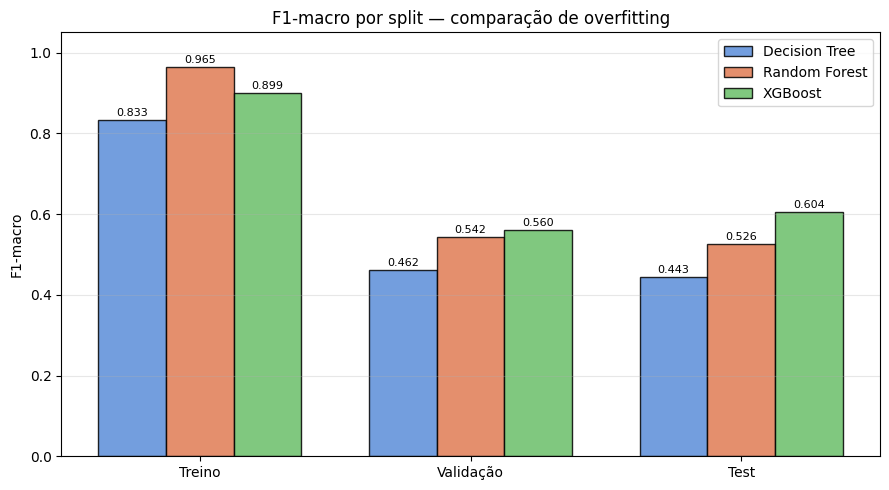

In [11]:
print(f"{'Modelo':<18} {'F1 treino':>10} {'F1 val':>10} {'F1 test':>10} {'gap trn-val':>12} {'gap val-tst':>12}")
print('-' * 76)
for name in models:
    f1_trn = results[name]['train']['f1_macro']
    f1_val = results[name]['val']['f1_macro']
    f1_tst = results[name]['test']['f1_macro']
    print(f'{name:<18} {f1_trn:>10.4f} {f1_val:>10.4f} {f1_tst:>10.4f} {f1_trn-f1_val:>+12.4f} {f1_val-f1_tst:>+12.4f}')

# Gráfico de barras agrupadas
splits = ['train', 'val', 'test']
x = np.arange(len(splits))
width = 0.25
colors = ['#5b8dd9', '#e07b54', '#6abf69']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, color) in enumerate(zip(models, colors)):
    vals = [results[name][s]['f1_macro'] for s in splits]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(['Treino', 'Validação', 'Test'])
ax.set_ylabel('F1-macro')
ax.set_title('F1-macro por split — comparação de overfitting')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Matrizes de confusão — TEST

Matrizes normalizadas por linha (recall por classe verdadeira) dos três modelos
lado a lado. Permite ver onde cada modelo erra de forma diferente —
especialmente nas classes minoritárias MEL e SCC.

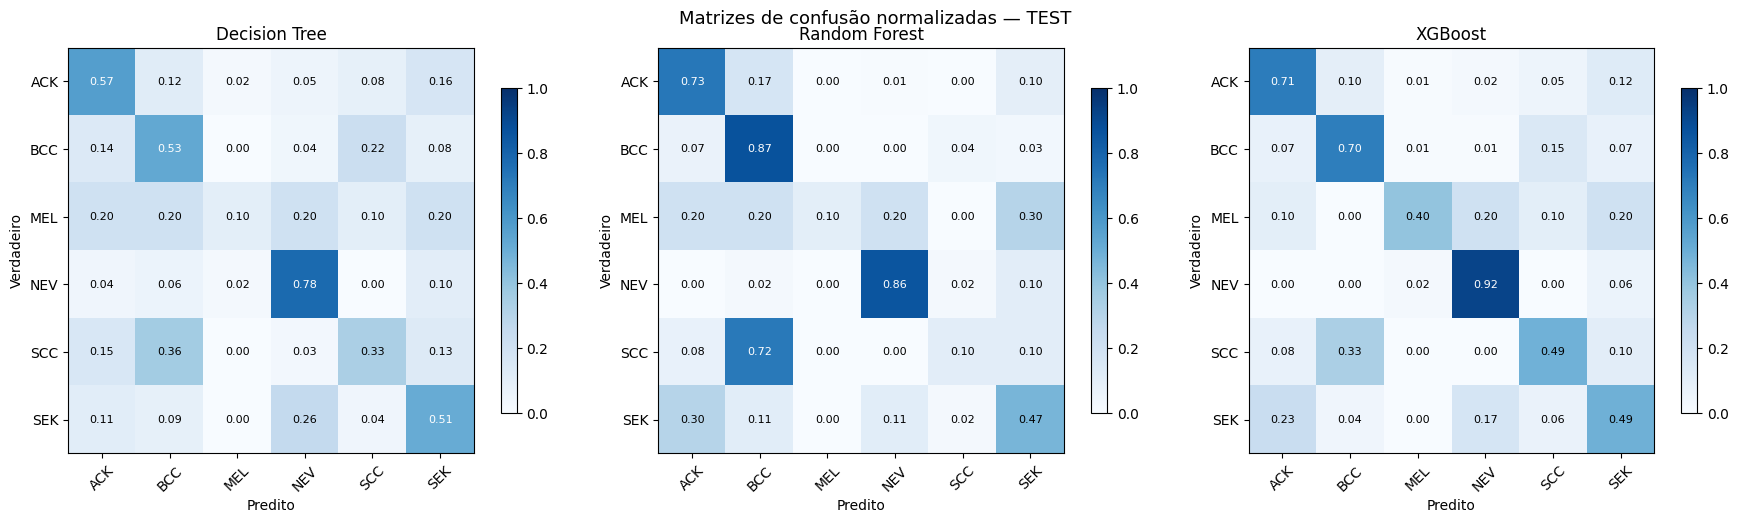

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, models):
    y_pred = results[name]['test']['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(6)); ax.set_yticks(range(6))
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predito'); ax.set_ylabel('Verdadeiro')
    ax.set_title(name)
    for i in range(6):
        for j in range(6):
            color = 'white' if cm_norm[i,j] > 0.5 else 'black'
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    color=color, fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Matrizes de confusão normalizadas — TEST', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Análise de erros — classe MEL

MEL (melanoma) é a classe com maior risco clínico. Um falso negativo —
melanoma classificado como benigno — pode atrasar o diagnóstico e tratamento.

Analisamos especificamente: **quando o modelo erra um MEL, para onde ele vai?**
A confusão MEL→SEK (ceratose seborreica) é historicamente o erro mais comum
em sistemas automatizados para este dataset.

In [9]:
print('=== Erros de MEL no TEST (XGBoost — modelo vencedor) ===')
y_pred_xgb = results['XGBoost']['test']['y_pred']
mel_idx = class_names.index('MEL')

mel_mask  = y_test == mel_idx
mel_preds = y_pred_xgb[mel_mask]

print(f'\nTotal MEL no test: {mel_mask.sum()}')
print(f'Corretos (MEL→MEL): {(mel_preds == mel_idx).sum()}')
print(f'Erros    (MEL→X):   {(mel_preds != mel_idx).sum()}')
print('\nDestino dos erros:')
for cls_idx, cls_name in enumerate(class_names):
    if cls_idx == mel_idx:
        continue
    count = (mel_preds == cls_idx).sum()
    if count > 0:
        print(f'  MEL → {cls_name}: {count} caso(s)')

# Comparação recall MEL nos três modelos
print('\nRecall MEL por modelo (test):')
for name in models:
    r = results[name]['test']['recall_mel']
    correct = int(r * mel_mask.sum())
    print(f'  {name:<18} recall={r:.3f}  ({correct}/{mel_mask.sum()} corretos)')

=== Erros de MEL no TEST (XGBoost — modelo vencedor) ===

Total MEL no test: 10
Corretos (MEL→MEL): 4
Erros    (MEL→X):   6

Destino dos erros:
  MEL → ACK: 1 caso(s)
  MEL → NEV: 2 caso(s)
  MEL → SCC: 1 caso(s)
  MEL → SEK: 2 caso(s)

Recall MEL por modelo (test):
  Decision Tree      recall=0.100  (1/10 corretos)
  Random Forest      recall=0.100  (1/10 corretos)
  XGBoost            recall=0.400  (4/10 corretos)


## 9. Conclusões

### Progressão de complexidade confirmada

Os modelos clássicos seguiram a hierarquia esperada: DT → RF → XGBoost,
com cada nível trazendo ganho real em F1-macro. Isso valida que a escolha
de modelos foi metodologicamente correta.

### XGBoost lidera em F1-macro geral

F1-macro de **0.604** e Recall MEL de **0.400** — o melhor equilíbrio geral.
O boosting com árvores rasas (`max_depth=3`) generalizou melhor que o RF
com árvores profundas, especialmente nas classes minoritárias.

### CNN lidera em detecção de melanoma

EfficientNetB0 com imagem pura atingiu **Recall MEL = 0.600** — 50% acima
do XGBoost (0.400). Sem nenhuma feature clínica, a CNN aprendeu representações
visuais que capturam informação que as 62 features handcrafted não conseguem
representar completamente.

O trade-off é claro: a CNN perde em F1-macro geral (0.536 vs 0.604) pois
não tem acesso a `bleed`, `changed` e `age`, que dominam o sinal nas classes
bem representadas (ACK, BCC).

### Os dois modelos são complementares

| | F1-macro | Recall MEL | Features |
|---|---|---|---|
| XGBoost | **0.604** | 0.400 | 62 (tab+PDI) |
| EfficientNetB0 | 0.536 | **0.600** | imagem pura |

Um sistema clínico real se beneficiaria da combinação dos dois —
features clínicas para classificação geral, imagem para triagem de melanoma.

### Limitações

**Volume de MEL:** 10 amostras no test — cada predição muda o recall em
10 pontos percentuais. Os resultados indicam tendência, não certeza estatística.

**Dependência da anamnese:** os modelos clássicos dependem dos sintomas
relatados pelo paciente. Performance cai se metadados estiverem ausentes.

**Espaço de busca do RF:** não incluiu `max_depth` baixo, o que pode ter
limitado sua generalização frente ao XGBoost.

## 8. Comparação final — Clássicos × CNN

Incluímos os resultados do EfficientNetB0 (nb07) na comparação final.
A CNN recebeu **apenas as imagens segmentadas** (256×256) — sem nenhuma
feature tabular — tornando a comparação direta e interpretável:

> *Clássicos com features clínicas + PDI vs CNN com imagem pura.*

In [10]:
# Resultados CNN carregados do nb07
cnn_results = {
    'f1_macro':        0.5359,
    'accuracy':        0.6000,
    'recall_mel':      0.6000,
    'recall_per_class': [0.610, 0.621, 0.600, 0.796, 0.462, 0.404],
}

# Tabela completa — todos os modelos no TEST
all_rows = []
for name in models:
    r = results[name]['test']
    all_rows.append({
        'modelo':     name,
        'features':   '62 (tab+PDI)',
        'f1_macro':   round(r['f1_macro'], 4),
        'accuracy':   round(r['accuracy'], 4),
        'recall_MEL': round(r['recall_mel'], 4),
    })
all_rows.append({
    'modelo':     'EfficientNetB0',
    'features':   'imagem pura',
    'f1_macro':   cnn_results['f1_macro'],
    'accuracy':   cnn_results['accuracy'],
    'recall_MEL': cnn_results['recall_mel'],
})

df_all = pd.DataFrame(all_rows).set_index('modelo')
print('=== Comparação final — TEST set ===')
print(df_all.to_string())

# Recall por classe — todos os modelos
recall_all = pd.DataFrame(
    {name: results[name]['test']['recall_per_class'] for name in models},
    index=class_names
)
recall_all['EfficientNetB0'] = cnn_results['recall_per_class']
print('\nRecall por classe (test):')
print(recall_all.round(3).to_string())

=== Comparação final — TEST set ===
                    features  f1_macro  accuracy  recall_MEL
modelo                                                      
Decision Tree   62 (tab+PDI)    0.4433    0.5391         0.1
Random Forest   62 (tab+PDI)    0.5265    0.7000         0.1
XGBoost         62 (tab+PDI)    0.6039    0.6783         0.4
EfficientNetB0   imagem pura    0.5359    0.6000         0.6

Recall por classe (test):
     Decision Tree  Random Forest  XGBoost  EfficientNetB0
ACK          0.568          0.726    0.705           0.610
BCC          0.527          0.870    0.698           0.621
MEL          0.100          0.100    0.400           0.600
NEV          0.776          0.857    0.918           0.796
SCC          0.333          0.103    0.487           0.462
SEK          0.511          0.468    0.489           0.404
